In [1]:
from pypot.dynamixel import DxlIO
from pypot.dynamixel.protocol.v1 import *

from glob import glob

#ports = glob('/dev/ttyACM*')
ports = glob('/dev/ttyUSB*')

assert len(ports) == 1

port = ports[0]
print('Connecting on port: {}'.format(port))
dxl_io = DxlIO(port,baudrate=2000000, timeout=0.005)

poulpe_id = 42
N_AXIS = 3

Connecting on port: /dev/ttyUSB0


In [2]:
dxl_io.flush()

In [3]:
ping_packet = DxlPingPacket(poulpe_id)
dxl_io._send_packet(ping_packet)

DxlStatusPacket(id=42, error=0, parameters=())

In [4]:
ping_packet.to_string()

b'\xff\xff*\x02\x01\xd2'

In [5]:
import binascii
print(binascii.hexlify(ping_packet.to_array()))

b'ffff2a0201d2'


In [6]:
import struct

def read_current_pos():
    pos_packet = DxlReadDataPacket(poulpe_id, 50, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_current_pos()

(0.013805823400616646, 0.04908737167716026, 0.03451455757021904)

In [7]:
def read_current_vel():
    pos_packet = DxlReadDataPacket(poulpe_id, 51, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    res = struct.unpack(N_AXIS * 'f', data)
    return res

read_current_vel()

(-2.5223372357846707e-44, -9.10844001811131e-44, -7.006492321624085e-45)

In [8]:
def read_current_torque():
    pos_packet = DxlReadDataPacket(poulpe_id, 52, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    res = struct.unpack(N_AXIS * 'f', data)
    return res

read_current_torque()

(151.004150390625, 204.5092315673828, 64.95677947998047)

In [9]:
def read_target_position():
    pos_packet = DxlReadDataPacket(poulpe_id, 60, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_target_position()

(0.0, 0.0, 0.0)

In [10]:
def read_axis_sensor():
    pos_packet = DxlReadDataPacket(poulpe_id, 90, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_axis_sensor()

(1.9908450841903687, 4.093294143676758, 3.1456196308135986)

In [11]:
def parse_state(data):
    #target=struct.unpack(N_AXIS * 'f', data[0:4*N_AXIS])
    #pos = struct.unpack(N_AXIS * 'f', data[4*N_AXIS:2*4*N_AXIS])
    #vel = struct.unpack(N_AXIS * 'f', data[2*4*N_AXIS:3*4*N_AXIS])
    #torque = struct.unpack(N_AXIS * 'f', data[3*4*N_AXIS:4*4*N_AXIS])
    #torque_on = struct.unpack(N_AXIS * '?', data[4*4*N_AXIS:(4*4+1)*N_AXIS])

    pos = struct.unpack(N_AXIS * 'f', data[0:4*N_AXIS])
    vel = struct.unpack(N_AXIS * 'f', data[4*N_AXIS:2*4*N_AXIS])
    torque = struct.unpack(N_AXIS * 'f', data[2*4*N_AXIS:3*4*N_AXIS])

    return pos, vel, torque

def read_full_state():
    pos_packet = DxlReadDataPacket(poulpe_id, 100, N_AXIS * (4*4))
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    return parse_state(data)

read_full_state()

((0.013805823400616646, 0.04908737167716026, 0.03451455757021904),
 (-2.5223372357846707e-44, -9.10844001811131e-44, -7.006492321624085e-45),
 (143.63417053222656, 211.81997680664062, 64.2546615600586))

In [12]:
def write_target_position(target):
    p = DxlWriteDataPacket(poulpe_id, 60, struct.pack(N_AXIS * 'f', *target))
    resp = dxl_io._send_packet(p,wait_for_status_packet=True)
    #print(resp)
    return parse_state(bytearray(resp.parameters))

#write_target_position([0.5, 0.5])
write_target_position([0.0, 0.0, 0.0])

((0.013805823400616646, 0.04908737167716026, 0.03451455757021904),
 (-2.5223372357846707e-44, -9.10844001811131e-44, -7.006492321624085e-45),
 (144.16146850585938, 198.41554260253906, 67.01100158691406))

In [13]:
def read_torque_enabled():
    p = DxlReadDataPacket(poulpe_id, 40, N_AXIS)
    resp = dxl_io._send_packet(p)
    data = bytearray(resp.parameters)
    torque = struct.unpack(N_AXIS * '?', data)
    return torque

read_torque_enabled()

(False, False, False)

In [14]:
def write_torque_enabled(torque):
    p = DxlWriteDataPacket(poulpe_id, 40, struct.pack(N_AXIS * '?', *torque))
    resp = dxl_io._send_packet(p)
    return resp

#write_torque_enabled([False, False])
write_torque_enabled([False, False, False])

DxlStatusPacket(id=42, error=0, parameters=())

In [68]:
#write_torque_enabled([True, True])
write_torque_enabled([True, True, True])

DxlStatusPacket(id=42, error=0, parameters=())

In [15]:
import time
import numpy as np

pos = []
send_target = []
read_target = []
axis_sensor = []
torque = []
vel = []
state=[]
t0 = time.time()
freq=0.5
cur=read_current_pos()
nbok=0
nberr=0
while True:
    if time.time() - t0 > 10:
        break

    target = [
        np.radians(2*360.0) * np.sin(2 * np.pi * freq * (time.time()-t0)), 
        np.radians(2*360.0) * np.sin(2 * np.pi * freq * (time.time()-t0)),
        np.radians(2*360.0) * np.sin(2 * np.pi * freq * (time.time()-t0)),
    ]
    try:
        state.append(write_target_position(target))
        send_target.append(target)
        #time.sleep(0.001)
        #cur=read_current_pos()
        #pos.append(cur)
        #time.sleep(0.001)
        #axis_sensor.append(read_axis_sensor())
        #torque.append(read_current_torque())
        #time.sleep(0.001)
        #vel.append(read_current_vel())
        #state.append(read_full_state())
        nbok+=1
    except:
        nberr+=1
        #print('err')
    time.sleep(0.0005)
    #cur=read_current_pos()
    #pos.append(cur)
    #read_target.append(cur)
    #time.sleep(0.01)
    #axis_sensor.append(read_axis_sensor())
    #time.sleep(0.001)
print(f'ok: {nbok} err: {nberr} ratio: {nberr/nbok}')

ok: 4985 err: 0 ratio: 0.0


In [ ]:
np.array(send_target) - np.array(pos)

In [ ]:
write_torque_enabled([False, False])

In [ ]:
np.array(send_target)

In [63]:
np.array(pos)

array([[ 0.        , -0.00076699,  0.        ],
       [ 0.01610679,  0.01687378,  0.02147573],
       [ 0.13499027,  0.13345629,  0.16260192],
       ...,
       [ 0.60745627,  0.6043883 ,  0.58291256],
       [ 0.43795142,  0.44408733,  0.41800967],
       [ 0.34591258,  0.34744656,  0.33824268]])

In [ ]:
write_target_position([0.0,0.0])

In [ ]:
read_target_position()

In [ ]:
read_current_pos()

In [91]:
import matplotlib.pyplot as plt

In [92]:
%matplotlib notebook

<IPython.core.display.Javascript object>


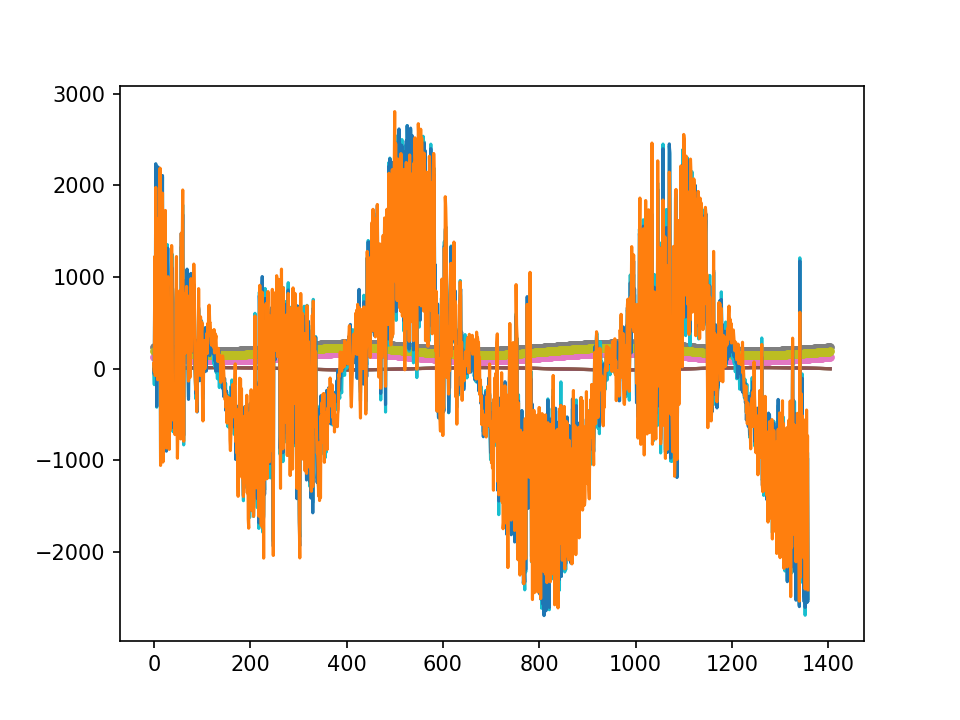

In [64]:
plt.plot(send_target)
plt.plot(np.array(pos))

In [65]:
plt.plot(np.degrees(np.array(axis_sensor)), '.')

<IPython.core.display.Javascript object>


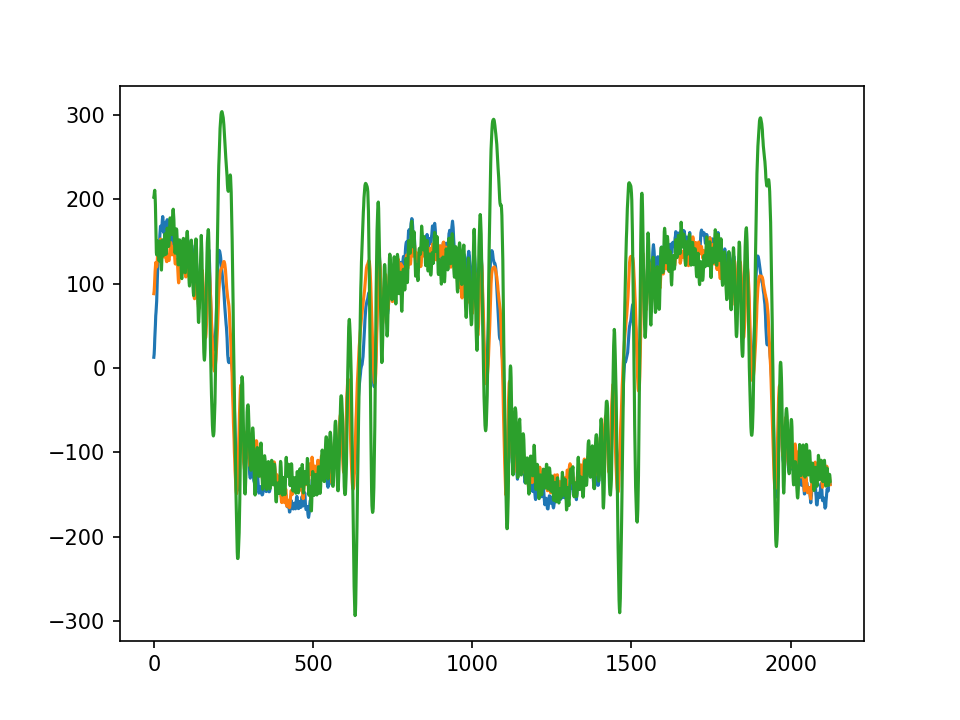

In [97]:
plt.plot(np.array(torque))
#plt.plot(np.array(vel))

<IPython.core.display.Javascript object>


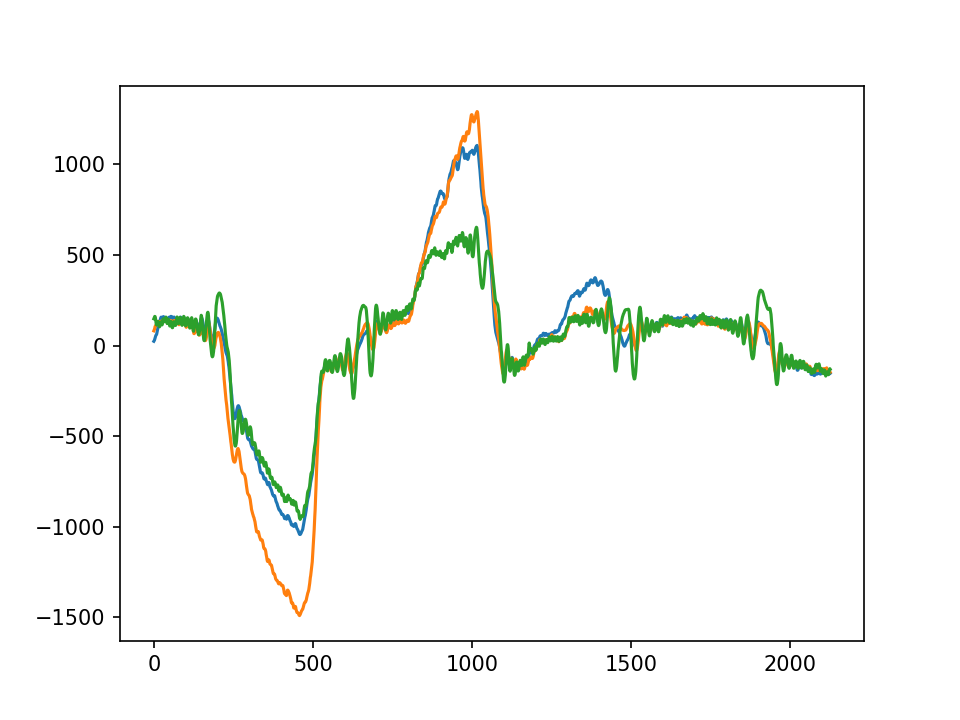

In [99]:
plt.plot(np.array(torque))

<IPython.core.display.Javascript object>


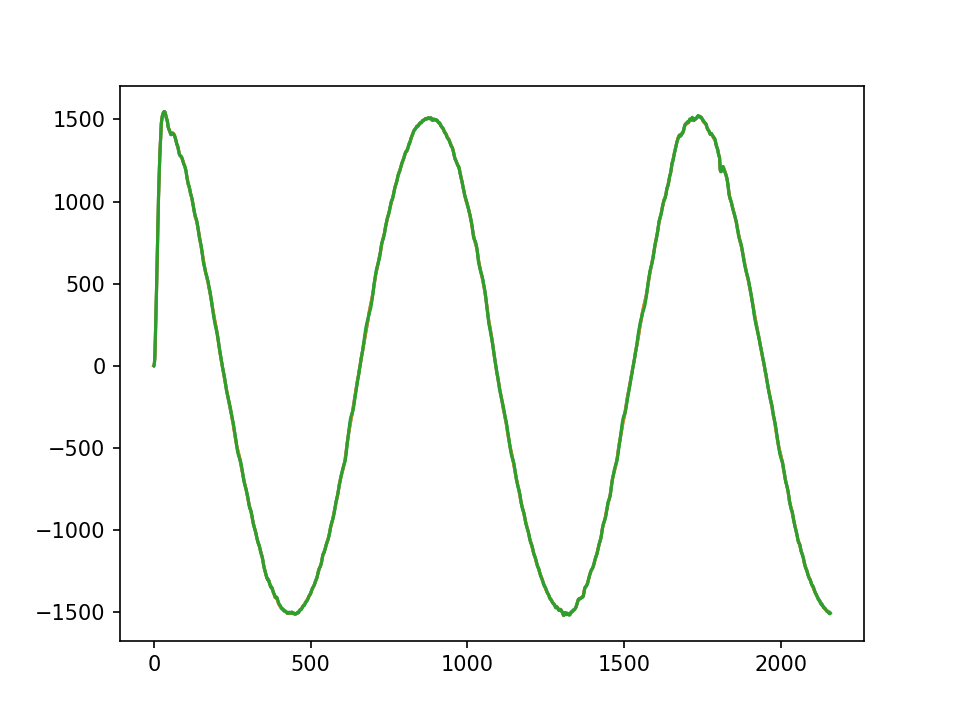

In [106]:
plt.plot(np.array(vel))

In [86]:
state=np.array(state)

In [89]:
state[:,2]

array([[ 0.        ,  0.        , -0.00076699],
       [ 0.00613592,  0.00690291,  0.00920388],
       [ 0.07516504,  0.07363106,  0.07439805],
       ...,
       [-0.54609704, -0.54763103, -0.52999026],
       [-0.46249509, -0.46402907, -0.44792229],
       [-0.38502908, -0.38809705, -0.39883491]])

<IPython.core.display.Javascript object>


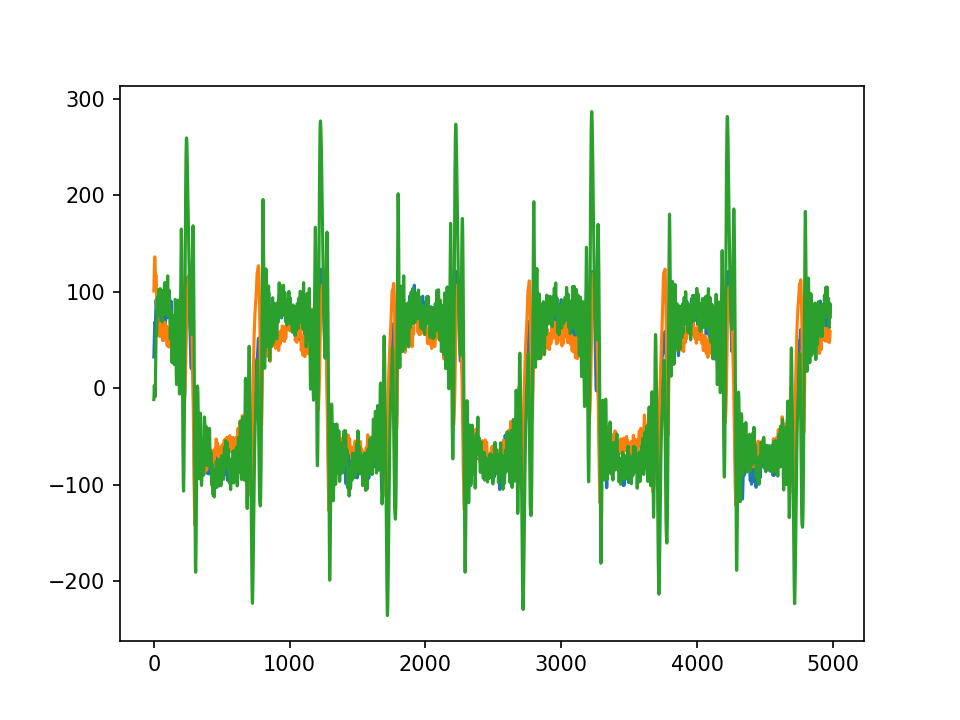

In [96]:
plt.plot(state[:,2])

In [ ]:
axis_sensor=np.array(axis_sensor)

In [ ]:
print(axis_sensor)

In [ ]:
np.isnan(axis_sensor).sum()/axis_sensor.shape[0]

In [ ]:
import serial

In [ ]:
s=serial.Serial("/dev/ttyACM0", 1000000, timeout=1)

In [ ]:
s.read()

In [ ]:
def rawping():
    s.write(b'\xff\xff*\x02\x01\xd2')
    ret=s.read(6)
    print(ret)

In [ ]:
rawping()

In [ ]:
from pypot.dynamixel.protocol.v1 import *
ping_packet = DxlPingPacket(42)

In [ ]:
ping_packet.to_string()

In [44]:
write_torque_enabled([False, False, False])

DxlStatusPacket(id=42, error=0, parameters=())

In [12]:
import time
nbok=0
nberr=0
for i in range(1000):
    #cur=read_current_pos()
    try:
        write_target_position([0.0,0.0,0.0])
        time.sleep(0.001)
        cur=read_current_pos()
        #write_target_position([0.0,0.0])
        #sensors=read_axis_sensor()
        #print(sensors)
        nbok+=1
    except:
        nberr+=1
        #print('err')
    #print(i)
    time.sleep(0.001)
print(f'ok: {nbok} err: {nberr} ratio: {nberr/nbok}')

ok: 1000 err: 0 ratio: 0.0


In [19]:
a=(86, 88, 207, 60, 157, 201, 44, 61, 33, 240, 25, 61, 18, 0, 0, 0, 6, 0, 0, 0, 5, 0, 0, 128, 140, 32, 19, 67, 85, 94, 103, 67, 61, 23, 159, 66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)

In [22]:
import numpy as np
a=np.array(a)

In [24]:
a.shape

(144,)